# 06 — Un modelo por zona (geo-clustering)

**Hipótesis (del EDA, nb 00):** la relación clima–rinde *cambia según la zona*
(fuerte en la Pampa húmeda, casi nula en el norte subtropical). Un único modelo
"pooled" tiene que promediar esas relaciones distintas. Entonces: ¿anda mejor
**un modelo por zona**, cada uno especializado en el clima de su región?

Lo probamos en serio y lo interpretamos zona por zona. Las zonas son las
**geográficas balanceadas** del nb 00 (KMeans sobre lat/lon de los departamentos),
y el modelo es el **XGBoost ganador (nb 03) + features agronómicas (nb 00)**, igual
para el pooled y para cada zona (comparación justa).

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
import datos, evaluacion as ev
from modelos import XGBoostRegressor

CULTIVO = 'soja'
N_ZONAS = 6
# Config ganadora de XGBoost (nb 03). Misma para pooled y por zona.
BEST = dict(max_depth=3, learning_rate=0.05, n_estimators=200, subsample=0.7,
            colsample_bytree=1.0, min_child_weight=1, reg_lambda=5.0,
            reg_alpha=1.0, gamma=1.0)
def fit_xgb(ds):
    return XGBoostRegressor(**BEST, random_state=42).fit(ds.X_train, ds.y_train)

# Panel con zonas + dataset pooled de referencia (base + agro).
panel = datos.assign_zonas(datos.load_panel('base'), n_zonas=N_ZONAS, method='geo')
ds_pool = datos.build_reg_dataset(panel, CULTIVO, dataset='base', use_agro=True)
print(f'{CULTIVO}: pooled train={len(ds_pool.y_train)} test={len(ds_pool.y_test)} '
      f'| {N_ZONAS} zonas geográficas')

[data] dedup panel: 28683 → 21418 filas (7265 duplicados espurios por lat/lon eliminados)
soja: pooled train=7838 test=954 | 6 zonas geográficas


## Composición de las zonas

Cada zona agrupa departamentos cercanos; las ordenamos de norte a sur (por latitud).

In [2]:
d = panel[panel.cultivo == CULTIVO].dropna(subset=['zona'])
comp = (d.groupby('zona')
          .agg(n=('rinde_kgha', 'size'),
               prov_principal=('provincia', lambda s: s.mode().iat[0]),
               rinde=('rinde_kgha', 'mean'), lat=('lat', 'mean'))
          .sort_values('lat', ascending=False))
comp

,n,prov_principal,rinde,lat
zona,,,,
z3,1431,SANTIAGO DEL ESTERO,"2,211.502",-26.735
z2,1150,CHACO,"1,887.848",-27.556
z0,768,CORDOBA,"2,346.165",-31.858
z5,2120,ENTRE RIOS,"2,445.885",-32.861
z1,2512,BUENOS AIRES,"2,226.169",-35.679
z4,1285,BUENOS AIRES,"2,019.535",-36.370


## Modelo pooled y su desempeño DENTRO de cada zona

Primero el pooled (un solo modelo con todas las filas). Además de la métrica global,
medimos su R² **dentro del test de cada zona** — así después comparamos, zona por
zona, contra el modelo especializado.

In [3]:
mp = fit_xgb(ds_pool)
pred_pool = mp.predict(ds_pool.X_test)
met_pool = ev.metricas(ds_pool.y_test, pred_pool)
print('POOLED (base+agro) global:', {k: round(v, 3) for k, v in met_pool.items()})

zt = ds_pool.meta_test['zona'].values
pool_por_zona = {z: ev.metricas(ds_pool.y_test[zt == z], pred_pool[zt == z])['r2']
                 for z in np.unique(zt)}

POOLED (base+agro) global: {'mae': 498.784, 'rmse': 644.369, 'r2': 0.294, 'mape': 28.107}


## Un modelo por zona

Para cada zona: su propio split temporal, codificación de depto, escalado y XGBoost
(todo calculado dentro de la zona). Reportamos la métrica por zona y la global
uniendo los tests de todas las zonas (que juntos son el test completo).

In [4]:
zds = datos.build_zona_datasets(CULTIVO, dataset='base', n_zonas=N_ZONAS,
                                method='geo', use_agro=True)
filas, yt_all, yp_all = [], [], []
for z, dz in zds.items():
    m = fit_xgb(dz); pr = m.predict(dz.X_test)
    mm = ev.metricas(dz.y_test, pr)
    filas.append({'zona': z, 'n_train': len(dz.y_train), 'n_test': len(dz.y_test),
                  'R2_pooled': pool_por_zona.get(z, np.nan),
                  'R2_por_zona': mm['r2'], 'RMSE_por_zona': mm['rmse']})
    yt_all.append(dz.y_test); yp_all.append(pr)
tabla_zona = pd.DataFrame(filas).sort_values('R2_por_zona', ascending=False)
tabla_zona

[data] dedup panel: 28683 → 21418 filas (7265 duplicados espurios por lat/lon eliminados)


,zona,n_train,n_test,R2_pooled,R2_por_zona,RMSE_por_zona
4,z4,1105,133,0.524,0.577,443.284
5,z5,1785,204,0.576,0.438,653.888
1,z1,2142,257,0.293,0.406,484.599
3,z3,1194,172,-0.180,0.200,585.720
0,z0,647,72,0.262,-0.039,777.651
2,z2,965,116,-0.278,-2.668,"1,657.809"


### Zona por zona: ¿dónde ayuda especializar?

La barra verde (modelo por zona) contra la azul (pooled) en el test de cada zona.

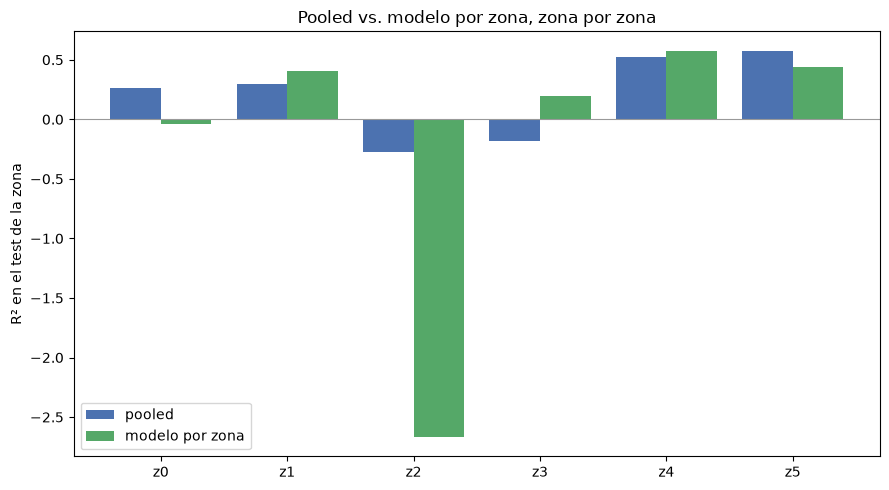

In [5]:
t = tabla_zona.sort_values('zona')
x = np.arange(len(t)); w = 0.4
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, t.R2_pooled, w, label='pooled', color='#4C72B0')
ax.bar(x + w/2, t.R2_por_zona, w, label='modelo por zona', color='#55A868')
ax.axhline(0, color='0.6', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(t.zona)
ax.set_ylabel('R² en el test de la zona')
ax.set_title('Pooled vs. modelo por zona, zona por zona'); ax.legend()
plt.tight_layout(); plt.show()

## El neto global y la zona que rompe

Uniendo los tests, comparamos pooled vs un-modelo-por-zona. Y miramos la zona que
colapsa: es el **norte subtropical**, justo donde el EDA (nb 00) mostró correlación
clima–rinde casi nula — ahí el modelo especializado sobreajusta ruido y extrapola
pésimo, arrastrando el promedio.

In [6]:
yt_all = np.concatenate(yt_all); yp_all = np.concatenate(yp_all)
met_zona_glob = ev.metricas(yt_all, yp_all)
comp_tabla = ev.tabla_comparativa([
    {'modelo': 'pooled (base+agro)', **met_pool},
    {'modelo': 'un modelo por zona', **met_zona_glob},
], ordenar_por='rmse')
peor = tabla_zona.sort_values('R2_por_zona').iloc[0]['zona']
print('Zona que colapsa:', peor, '->',
      dict(panel[(panel.cultivo == CULTIVO) & (panel.zona == peor)]
           .provincia.value_counts().head(3)))
comp_tabla

Zona que colapsa: z2 -> {'CHACO': np.int64(508), 'SANTA FE': np.int64(176), 'MISIONES': np.int64(162)}


,modelo,mae,rmse,r2,mape
0,pooled (base+agro),498.784,644.369,0.294,28.107
1,un modelo por zona,510.087,789.785,-0.060,27.285


## Interpretación

- **Especializar por zona ayuda donde la señal climática es fuerte y hay datos**
  (las zonas pampeanas: R² sube claramente sobre el pooled) — la hipótesis del EDA
  se cumple *ahí*.
- **Pero rompe en el norte subtropical**: poca señal clima–rinde + menos datos por
  modelo ⇒ sobreajuste y extrapolación catastrófica en test. Esa zona sola hunde la
  métrica global.
- **Neto global: un modelo por zona NO le gana al pooled.** El pooled comparte
  "fuerza estadística" entre zonas (regulariza las zonas ruidosas con las buenas) y
  ya captura lo espacial vía `depto_enc`. Fragmentar los datos pierde eso.

### Cómo hacer que las zonas sí paguen (próximos pasos)
1. **Split selectivo**: modelo por zona solo en las zonas donde mejora (Pampa) y
   pooled para las ruidosas — lo mejor de los dos.
2. **Partial pooling / jerárquico**: un modelo que comparte parámetros entre zonas
   pero deja variar la relación clima–rinde (efectos por zona), sin fragmentar.
3. **Más regularización en zonas chicas/ruidosas** (menos profundidad, más shrinkage)
   o un mínimo de filas más alto por zona.
4. **Cambiar el target a residuo/anomalía** por zona (sacar el nivel espacial), que
   es lo que de verdad depende del clima.

**Conclusión:** el geo-clustering es muy útil como *diagnóstico* (muestra dónde el
clima predice y dónde no), pero "un modelo por zona" a secas no mejora el global;
el camino es el pooling parcial o el split selectivo.